In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
credit_data = pd.read_csv('../data/cs-training.csv')
credit_data.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


the first column is useless(it repeats the id column but indexing starts with 1) and we should delete it

In [3]:
credit_data = credit_data.drop('Unnamed: 0', axis=1)
credit_data.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
credit_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

the dataset has only numerical dtypes so there is no need to use encoding. dataset has 2 columns with null values: MonthlyIncome an NumberOfDependents. 

In [5]:
credit_data.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [6]:
total_cells = np.prod(credit_data.shape)
total_missing = credit_data.isnull().sum().sum()
percent_missing = (total_missing/total_cells) * 100
percent_missing

np.float64(2.03969696969697)

only 2% of data is missing but still it is required to clean these 2 columns from null values

In [7]:
credit_data[['MonthlyIncome', 'NumberOfDependents']].describe()

,MonthlyIncome,NumberOfDependents
count,1.202690e+05,146076.000000
mean,6.670221e+03,0.757222
std,1.438467e+04,1.115086
min,0.000000e+00,0.000000
25%,3.400000e+03,0.000000
50%,5.400000e+03,0.000000
75%,8.249000e+03,1.000000
max,3.008750e+06,20.000000


In [8]:
def build_mean_median_chart(column, value_limit):
    median_val = credit_data[column].median()
    mean_val = credit_data[column].mean()

    plt.figure(figsize=(10, 4))

    sns.kdeplot(credit_data[column], color='dodgerblue', fill=True, alpha=0.15, label='Density')

    plt.axvline(x=median_val, color='green', linestyle='--', linewidth=3, label=f'Median: {median_val}')
    plt.axvline(x=mean_val, color='red', linestyle='--', linewidth=3, label=f'Mean: {mean_val:.2f}')

    plt.xlim(0, value_limit)

    plt.title(f'Mean and median of {column}', fontsize=12)
    plt.xlabel(column, fontsize=10)
    plt.yticks([]) 
    plt.legend(fontsize=11, loc='upper right')
    plt.grid(axis='x', alpha=0.5)

    plt.show()

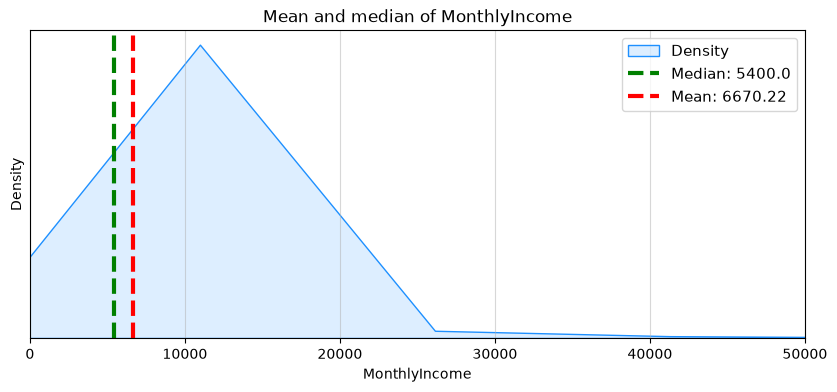

In [9]:
build_mean_median_chart('MonthlyIncome', 50000)

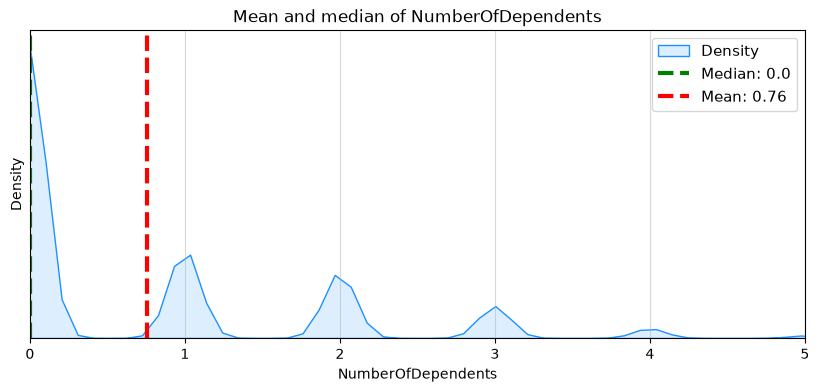

In [10]:
build_mean_median_chart('NumberOfDependents', 5)

median and mean are different (data is skewed) so it is safer to use median as a value for imputation

In [11]:
monthly_income_median = credit_data['MonthlyIncome'].median()
credit_data['MonthlyIncome'] = credit_data['MonthlyIncome'].fillna(monthly_income_median)

num_dependents_median = credit_data['NumberOfDependents'].median()
credit_data['NumberOfDependents'] = credit_data['NumberOfDependents'].fillna(num_dependents_median)

credit_data.isnull().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

now dataset doesn't have any missing values

In [12]:
credit_data.duplicated().sum().item()

767

dataset has 767 duplicated rows it may leads to overfitting. these rows should be deleted from dataset 

In [13]:
credit_data = credit_data.drop_duplicates()
credit_data.duplicated().sum().item()

0

In [14]:
credit_data = credit_data.reset_index()
credit_data = credit_data.drop('index', axis=1)
credit_data

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149228,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149229,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149230,0,0.246044,58,0,3870.000000,5400.0,18,0,1,0,0.0
149231,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


reset_index() because we've deleted duplicated values

In [15]:
credit_data.nunique()

SeriousDlqin2yrs                             2
RevolvingUtilizationOfUnsecuredLines    125728
age                                         86
NumberOfTime30-59DaysPastDueNotWorse        16
DebtRatio                               114194
MonthlyIncome                            13594
NumberOfOpenCreditLinesAndLoans             58
NumberOfTimes90DaysLate                     19
NumberRealEstateLoansOrLines                28
NumberOfTime60-89DaysPastDueNotWorse        13
NumberOfDependents                          13
dtype: int64

In [16]:
credit_data.apply(lambda x: x.unique())

SeriousDlqin2yrs                                                                   [1, 0]
RevolvingUtilizationOfUnsecuredLines    [0.766126609, 0.957151019, 0.65818014, 0.23380...
age                                     [45, 40, 38, 30, 49, 74, 57, 39, 27, 51, 46, 7...
NumberOfTime30-59DaysPastDueNotWorse    [2, 0, 1, 3, 4, 5, 7, 10, 6, 98, 12, 8, 9, 96,...
DebtRatio                               [0.802982129, 0.121876201, 0.085113375, 0.0360...
MonthlyIncome                           [9120.0, 2600.0, 3042.0, 3300.0, 63588.0, 3500...
NumberOfOpenCreditLinesAndLoans         [13, 4, 2, 5, 7, 3, 8, 9, 6, 10, 14, 22, 17, 1...
NumberOfTimes90DaysLate                 [0, 1, 3, 2, 5, 4, 98, 10, 9, 6, 7, 8, 15, 96,...
NumberRealEstateLoansOrLines            [6, 0, 1, 3, 4, 2, 5, 8, 7, 9, 17, 15, 10, 12,...
NumberOfTime60-89DaysPastDueNotWorse           [0, 1, 2, 5, 3, 98, 4, 6, 7, 8, 96, 11, 9]
NumberOfDependents                      [2.0, 1.0, 0.0, 3.0, 4.0, 5.0, 6.0, 8.0, 7.0, ...
dtype: obj

now we can separate continuous features from discrete and use different plots for visualization

In [17]:
credit_data.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,149233.000000,149233.000000,149233.000000,149233.000000,149233.000000,1.492330e+05,149233.000000,149233.000000,149233.000000,149233.000000,149233.000000
mean,0.067036,6.077045,52.298145,0.388386,354.808254,6.426774e+03,8.488082,0.232435,1.023473,0.206811,0.741177
std,0.250085,250.396053,14.714050,3.779712,2042.891693,1.292246e+04,5.134233,3.752133,1.130304,3.736132,1.108596
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.030210,41.000000,0.000000,0.178098,3.900000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154285,52.000000,0.000000,0.368578,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.555959,63.000000,0.000000,0.877090,7.409000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


/var/folders/ls/lmkg84h154l871cbkwhq2nnc0000gn/T/ipykernel_28565/1413375657.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=credit_data, x='SeriousDlqin2yrs', palette='Set2')


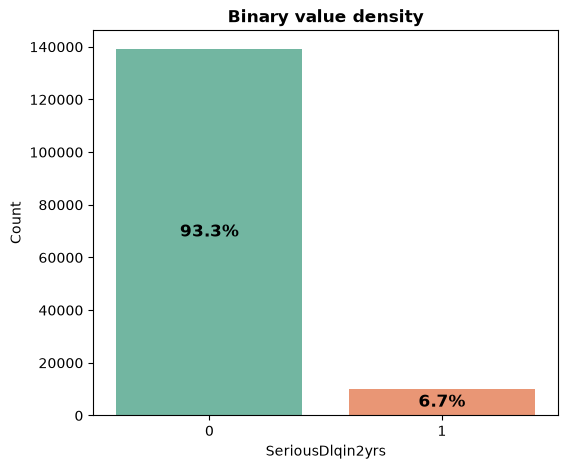

In [18]:
plt.figure(figsize=(6, 5))
 
ax = sns.countplot(data=credit_data, x='SeriousDlqin2yrs', palette='Set2')

total = len(credit_data['SeriousDlqin2yrs'])

for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    
    ax.annotate(
        percentage, 
        (p.get_x() + p.get_width() / 2., p.get_height() / 2.), 
        ha='center', 
        va='center', 
        xytext=(0, 0), 
        textcoords='offset points',
        fontsize=12, 
        fontweight='bold', 
        color='black' 
    )


plt.title('Binary value density', fontsize=12, fontweight='bold')
plt.xlabel('SeriousDlqin2yrs', fontsize=10)
plt.ylabel('Count', fontsize=10)

plt.show()

now we can see that mostly (93.3%) people pay in time  

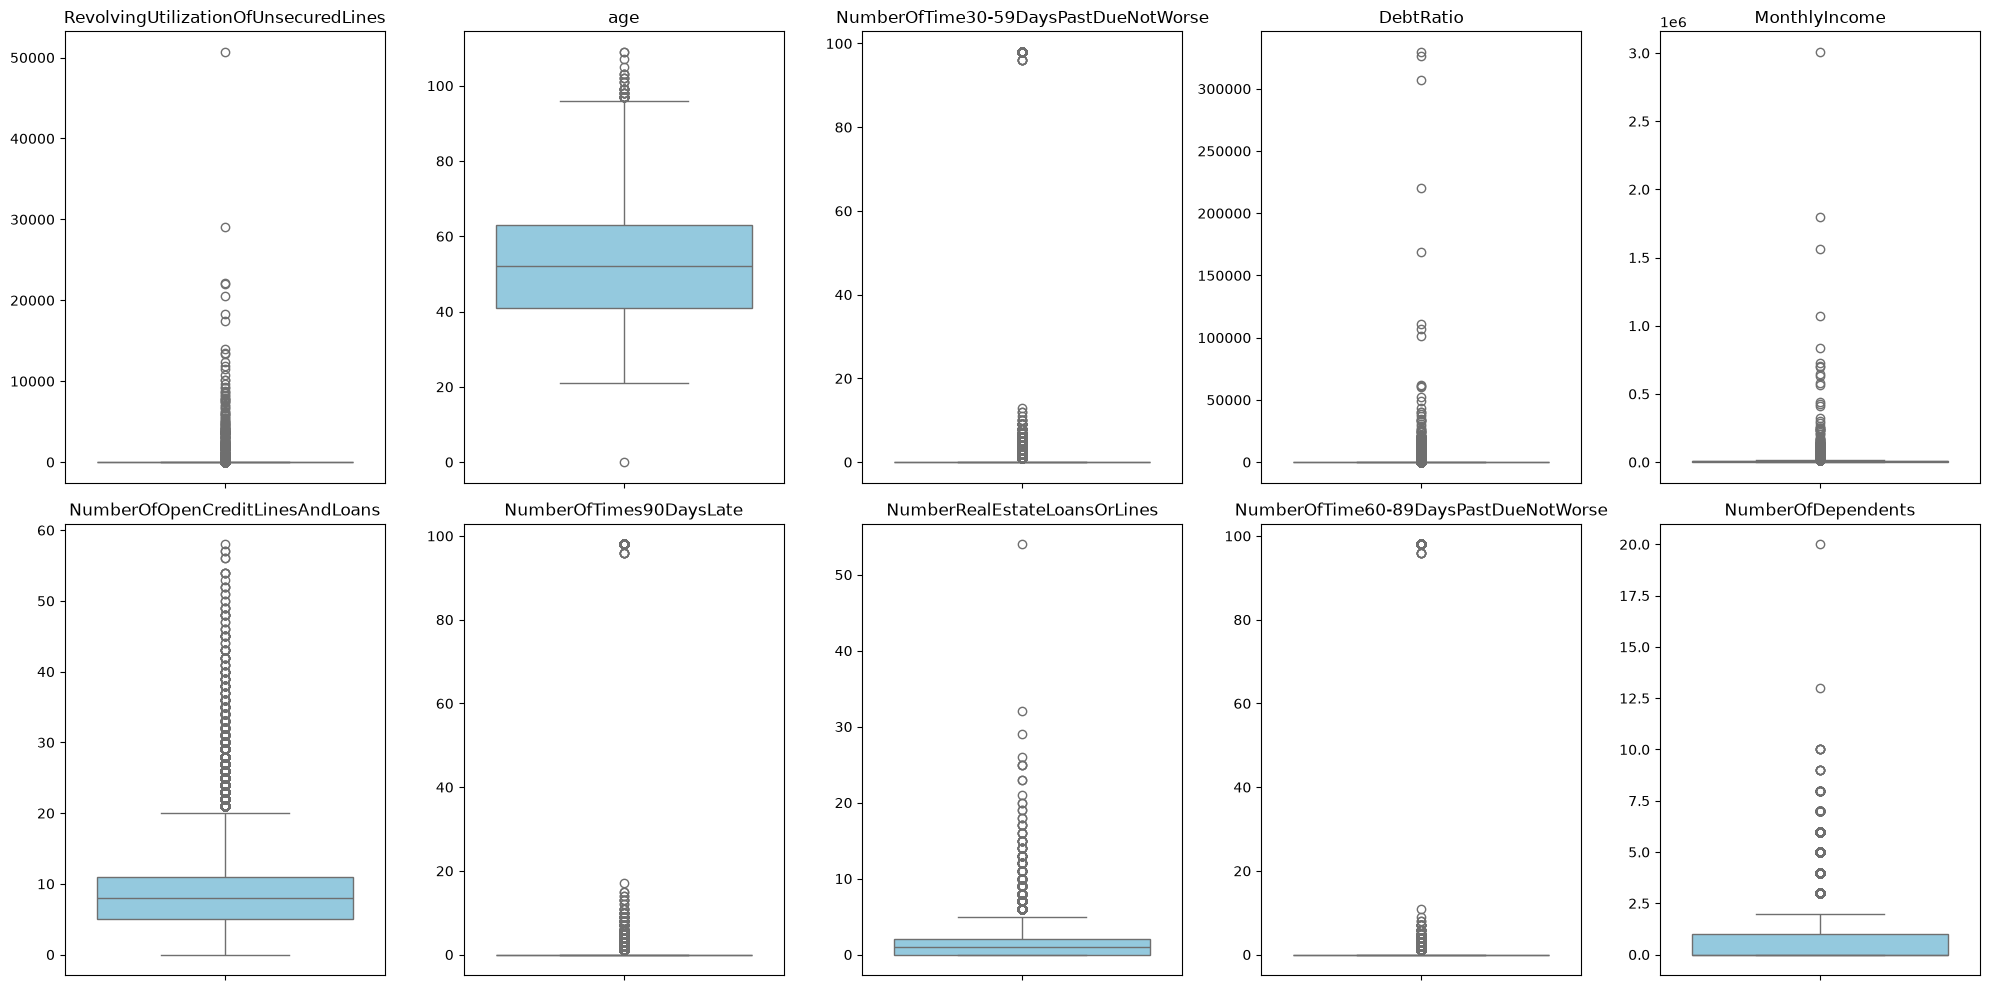

In [19]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()  

features = credit_data.columns[1:]

for i, col in enumerate(features):
    sns.boxplot(data=credit_data, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(col)
    axes[i].set_ylabel('') 

plt.tight_layout()
plt.show()

all features have a lot of outliers. outliers in age and number of dependences features seem unrealistic. there are several values in the features NumberOfTime30-59DaysPastDueNotWorse, NumberOfTimes90DaysLate, and NumberOfTime60-89DaysPastDueNotWorse features, these numbers repeat in all 3 features. As we could see previously, RevolvingUtilizationOfUnsecuredLines in general has values smaller than 1 and some outliers have values under 50,000. 

In [20]:
print(credit_data['NumberOfTime30-59DaysPastDueNotWorse'].sort_values(ascending=False)[:220])
print(credit_data['NumberOfTime60-89DaysPastDueNotWorse'].sort_values(ascending=False)[:220])
print(credit_data['NumberOfTimes90DaysLate'].sort_values(ascending=False)[:217])

62478     98
4415      98
11353     98
37842     98
29267     98
          ..
83858     96
80247     13
4538      12
57793     12
148793    11
Name: NumberOfTime30-59DaysPastDueNotWorse, Length: 220, dtype: int64
148477    98
25703     98
126993    98
126913    98
23539     98
          ..
93738     96
56953     11
68751      9
68317      8
23929      8
Name: NumberOfTime60-89DaysPastDueNotWorse, Length: 220, dtype: int64
33096     98
106294    98
43868     98
69865     98
70611     98
          ..
119515    96
83858     96
93738     96
69248     96
102904    17
Name: NumberOfTimes90DaysLate, Length: 217, dtype: int64


216 values in each column are the same. we may conclude that these values aren't informative.

firslty, we should fix the values for age and NumberOfDependents features. The anomaly values will be changed with median values.

In [21]:
print(credit_data['age'].median().item())
print(credit_data['age'][credit_data['age'] == 0])

52.0
65493    0
Name: age, dtype: int64


we've checked the value that we should change so we can check it later. 

In [ ]:
for i in range(credit_data.shape[0]):
    credit_data.iloc[i, 2] = credit_data['age'].median() if credit_data.iloc[i, 2] == 0 else credit_data.iloc[i, 2]

print(credit_data['age'].iloc[65493])

52


now we don't have an outlier in the age feature.

secondly, let's do the same with NumberOfDependents. Let 10 be the maximum value. 

In [23]:
credit_data['NumberOfDependents'][credit_data['NumberOfDependents'] > 10]

6297      20.0
127433    13.0
Name: NumberOfDependents, dtype: float64

we have only 2 values so we should change it to median value

In [ ]:
print(credit_data['NumberOfDependents'].median())

for i in range(credit_data.shape[0]):
    credit_data.iloc[i, 10] = credit_data['NumberOfDependents'].median() if credit_data.iloc[i, 10].item() > 10 else credit_data.iloc[i, 10]

print(credit_data['NumberOfDependents'].iloc[6297])
print(credit_data['NumberOfDependents'].iloc[127433])

0.0
0.0
0.0


thirdly, we should make an additional column with flag. and then we'll change outliers.

In [25]:
for i in range(credit_data.shape[0]):
    if (credit_data.iloc[i, 3].item() >= 96) or (credit_data.iloc[i, 7].item() >= 96) or (credit_data.iloc[i, 9].item() >= 96):
        credit_data.loc[i, 'has_special_value'] = 1
    else:
        credit_data.loc[i, 'has_special_value'] = 0


In [26]:
credit_data['has_special_value'].sum()

np.float64(216.0)

the column 'has_special_value' has exactly 2016 values of 1. 

In [27]:
credit_data['has_special_value'].unique()

array([0., 1.])

In [28]:
def change_special_value(col):
    for i in range(credit_data.shape[0]):
        credit_data.iloc[i, col] = credit_data.iloc[:, col].median() if credit_data.iloc[i, col].item() >= 96 else credit_data.iloc[i, col]
    
    return 

In [29]:
change_special_value(3)
change_special_value(7)
change_special_value(9)

In [30]:
print(credit_data['NumberOfTime30-59DaysPastDueNotWorse'].sort_values(ascending=False)[:220])
print(credit_data['NumberOfTime60-89DaysPastDueNotWorse'].sort_values(ascending=False)[:220])
print(credit_data['NumberOfTimes90DaysLate'].sort_values(ascending=False)[:217])

80247     13
4538      12
57793     12
148793    11
10146     10
          ..
37882      6
4197       6
71059      6
16272      6
45472      6
Name: NumberOfTime30-59DaysPastDueNotWorse, Length: 220, dtype: int64
56953     11
68751      9
23929      8
68317      8
21851      7
          ..
92033      3
74203      3
5912       3
145201     3
146961     3
Name: NumberOfTime60-89DaysPastDueNotWorse, Length: 220, dtype: int64
102904    17
148338    15
30613     15
126092    14
89379     14
          ..
126808     5
15466      5
103566     5
103570     5
14583      5
Name: NumberOfTimes90DaysLate, Length: 217, dtype: int64


now these columns son't have any code. 

<Axes: >

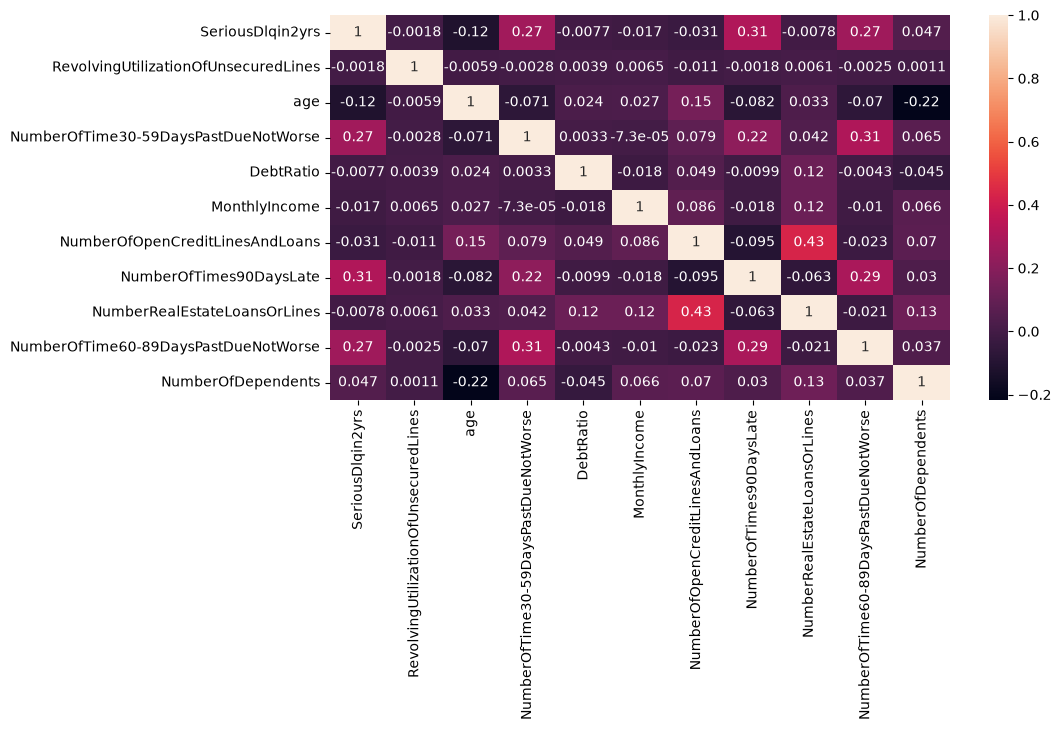

In [31]:
plt.figure(figsize=(10, 5))
correlation_matrix = credit_data.iloc[:, :-1].corr()
sns.heatmap(data=correlation_matrix, annot=True)

Strong correlation between (they correlate with each other):
- age and: NumberOfOpenCreditLinesAndLoans, NumberOfDependents
- NumberOfTime30-59DaysPastDueNotWorse and: NumberOfTimes90DaysLate, NumberOfTime60-89DaysPastDueNotWorse
- NumberRealEstateLoansOrLines and: DeptRatio, MonthlyIncome, NumberOfOpenCreditLinesAndLoans, NumberOfDependents
- NumberOfTimes90DaysLate and NumberOfTime60-89DaysPastDueNotWorse

but still every feature depends on target feature.

<Axes: >

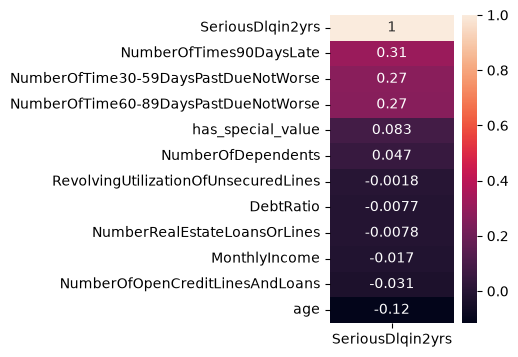

In [32]:
correlation_matrix = credit_data.corr()

target_col = credit_data.iloc[:, 0].name
single_corr = correlation_matrix[[target_col]].sort_values(by=target_col, ascending=False)
plt.figure(figsize=(2, 4))  
sns.heatmap(data=single_corr, annot=True)

age, NumberOfTime30-59DaysPastDueNotWorse, NumberOfTimes90DaysLate, and NumberOfTime60-89DaysPastDueNotWorse influence target most.